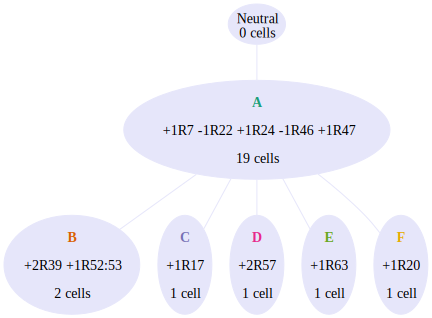

In [2]:
import pickle

graph_tree_path = "/home/vittorio.zampinetti/Cellmates/reproducibility/workflows/cnasim_makedata/results/A2_0/0/scicone_out/scicone_test_tree_graphviz_src.pkl"
pickle.load(open(graph_tree_path, "rb"))  # graphviz Source obj
# plot graph



In [5]:
import numpy as np

cnv_data_path = "/home/vittorio.zampinetti/Cellmates/reproducibility/workflows/cnasim_makedata/results/A2_0/0/scicone_out/scicone_test_cnv.npy"
cnv_matrix = np.load(cnv_data_path)

In [7]:
import anndata
import scgenome.plotting as pl

adata_path = "/home/vittorio.zampinetti/Cellmates/reproducibility/workflows/cnasim_makedata/results/A2_0/0/anndata.h5ad"
adata = anndata.read_h5ad(adata_path)
adata.layers['scicone-cn'] = cnv_matrix
adata

AnnData object with n_obs × n_vars = 25 × 2879
    obs: 'normal', 'clone'
    var: 'chr', 'start', 'end'
    uns: 'ancestral-cn', 'ancestral-cnA', 'ancestral-cnB', 'ancestral-names', 'cell-tree-newick', 'clonal-tree-newick', 'clone-id-tree-newick', 'cnasim-params'
    layers: 'Acount', 'Astate', 'Bcount', 'Bstate', 'state', 'scicone-cn'

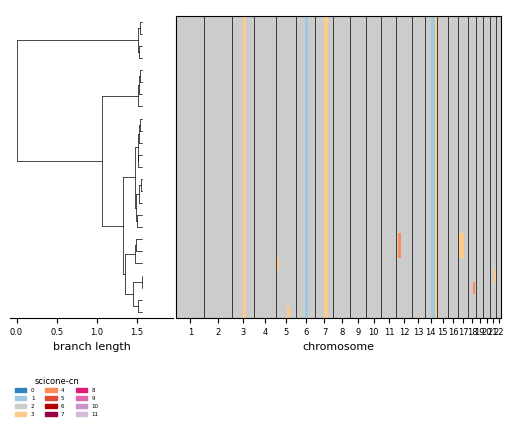

In [8]:
from Bio import Phylo
from io import StringIO

bio_tree = Phylo.read(StringIO(adata.uns['cell-tree-newick']), format='newick')
g = pl.plot_cell_cn_matrix_fig(adata, layer_name='scicone-cn', tree=bio_tree)

Observations:
- it seems like the maximum cn is 4
- CN events look wider than should be
- some cn events have been ignored (see upper clades)
- tree is clonal - how to infer sc-tree?

Possible improvement:
- change threshold param for boundaries, maybe too sensitive
- increase max_cn
- include genome annotation to separate chromosomes

## Original CN data

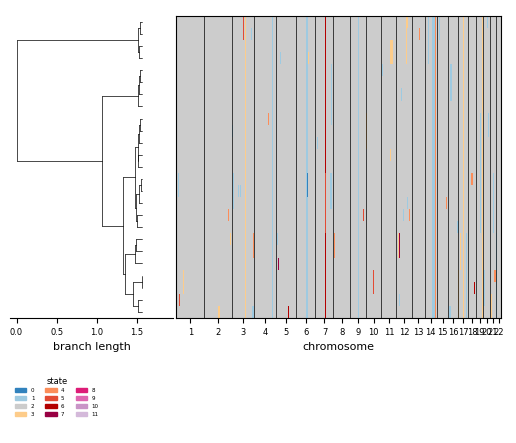

In [9]:
g = pl.plot_cell_cn_matrix_fig(adata, layer_name='state', tree=bio_tree)